In [1]:
import torch
import numpy as np

from torch.utils.data import DataLoader

* Import all
* Track and graph the loss 
* Look at graph, make adjustments to the adam optimizer
* repeat.

Were working with exactly ONE function here and modifying our training loop as we do it. 

In [17]:


def gen_hypercubes(d, no_loading=False):
    try:
        if no_loading:
            raise(Exception("No loading files"))
        data = np.load(f"matrices{d}.npz")
        hpoints1 = data['hpoints1']
        hpoints2 = data['hpoints2']
        return hpoints1, hpoints2
    except:
        #non reduced
        hpoints1 = np.ones((d,2**(d-1)*d))
        hpoints2 = np.ones((d,2**(d-1)*d))

        #testing - gen all pairs, gen half
        j=0
        for i1 in range(2**d):
            for i2 in range(d):

                if 1<<i2>i1:
                    break
                if (i1&(1<<i2))!=0:
                    v1=i1
                    v2=i1^(1<<i2)
                    for j2 in range(d):
                        hpoints1[j2, j] = (-2* ((v1&(1<<j2)) !=0 ))+1
                        hpoints2[j2, j] = (-2* ((v2&(1<<j2)) !=0 ))+1
                    j += 1
        np.savez(f"matrices{d}.npz", hpoints1=hpoints1, hpoints2=hpoints2)
        return hpoints1, hpoints2


def intersection_matrix(d, h, edges):
    A = h.reshape(-1, d + 1)[:, :-1]
    b = h.reshape(-1, d + 1)[:, -1]
    intersection_func = lambda e: torch.multiply(
        torch.matmul(A, e[0:d]) - b,
        torch.matmul(A, e[d:]) - b
    )
    return torch.vmap(intersection_func, in_dims=0, out_dims=0)(edges.reshape(-1,d*2))

def get_k(d,h):
    return h.reshape(-1,d+1).shape[0]

def count(d,h,edges):
    return torch.sum(torch.vmap(torch.max)(intersection_matrix(d,h.reshape(-1,d+1), edges.reshape(-1,d*2))<0))


def apply_G(d,h,G,G_agg, edge_subset):
    int_matrix = intersection_matrix(d, h, edge_subset)
    agg = G_agg(torch.vmap(G)(int_matrix))
    return agg

def run_adam(d, h_desired, dist, G, G_agg,  batch_size, edge_set, total_iter=60, randomness=False, scheduler_fac=None):
    loss_array = [] 
    val_array = [] 
    val0 = apply_G(d,h_desired,G,G_agg, edge_set)

    v = torch.rand(h_desired.shape) - .5
    v = v / torch.linalg.norm(v.flatten()) * dist
    edge_loader = DataLoader(edge_set, batch_size=batch_size, shuffle=True)
    h = torch.tensor(h_desired+v).double().requires_grad_(True)
    optimizer = torch.optim.Adam([h],lr=0.01)
    scheduler = scheduler_fac(optimizer) if scheduler_fac is not None else None
    if batch_size>-1:
        for i in range(total_iter):
            for edge_subset in edge_loader:

                # iterate x timees, iterate through edges
                optimizer.zero_grad()
                agg=apply_G(d,h,G,G_agg, edge_subset)
                agg.backward()

                if randomness:
                    with torch.no_grad():
                        if h.grad is not None:
                            # Noise scale proportional to current gradient magnitude or fixed decay
                            noise = torch.randn_like(h.grad) * 0.001
                            h.grad += noise
                with torch.no_grad():
                    loss_array.append(torch.linalg.norm(h.flatten() - h_desired.flatten()).item())
                    val_array.append((apply_G(d,h,G,G_agg, edge_subset) - val0).item())
                optimizer.step()
                if scheduler is not None:
                    scheduler.step()
    else:
        for i in range(total_iter):
            # iterate x timees, iterate through edges
            optimizer.zero_grad()
            agg=apply_G(d,h,G,G_agg, edge_set)
            agg.backward()
            if randomness:
                with torch.no_grad():
                    if h.grad is not None:
                        # Noise scale proportional to current gradient magnitude or fixed decay
                        noise = torch.randn_like(h.grad) * 0.001
                        h.grad += noise
            with torch.no_grad():
                loss_array.append(torch.linalg.norm(h.flatten() - h_desired.flatten()).item())
                val_array.append((apply_G(d,h,G,G_agg, edge_subset) - val0).item())
            optimizer.step()
            if scheduler is not None:
                scheduler.step()
    print(f"k: {get_k(d,h)} d: {d} count: {count(d,h,edge_set)}")
    return loss_array, val_array




def run_LBFGS(d, h_desired, dist, G, G_agg, batch_size, edge_set, total_iter=60, randomness=False):
    loss_array = [] 
    val_array = [] 
    val0 = apply_G(d,h_desired,G,G_agg, edge_set)

    v = torch.rand(h_desired.shape) - .5
    v = v / torch.linalg.norm(v.flatten()) * dist
    edge_loader = DataLoader(edge_set, batch_size=batch_size, shuffle=True)
    h = torch.tensor(h_desired+v).double().requires_grad_(True)
    optimizer = torch.optim.LBFGS([h],lr=0.01)
    def closure():
        optimizer.zero_grad()
        agg=apply_G(d,h,G,G_agg, edge_subset)
        agg.backward()
        if randomness:
            with torch.no_grad():
                if h.grad is not None:
                    # Noise scale proportional to current gradient magnitude or fixed decay
                    noise = torch.randn_like(h.grad) * 0.001
                    h.grad += noise
        return agg-val0
    if batch_size>-1:
        for i in range(total_iter):
            for edge_subset in edge_loader:

                # iterate x timees, iterate through edges

                optimizer.step(closure)

                with torch.no_grad():
                    loss_array.append(torch.linalg.norm(h.flatten() - h_desired.flatten()).item())
                    val_array.append((apply_G(d,h,G,G_agg, edge_subset) - val0).item())
                
    else:
        for i in range(total_iter):
            optimizer.step()
            with torch.no_grad():
                loss_array.append(torch.linalg.norm(h.flatten() - h_desired.flatten()).item())
                val_array.append((apply_G(d,h,G,G_agg, edge_subset) - val0).item())
            
    print(f"k: {get_k(d,h)} d: {d} count: {count(d,h,edge_set)}")
    return loss_array, val_array



def run_adam_reboot(d, h_desired, dist, G, G_agg, batch_number, edge_set, reboot_dist, total_iter=60, lr=.01, penalty=None):
    #loss_array = [] 
    #val_array = [] 
    loss_array = []
    val0 = apply_G(d,h_desired,G,G_agg, edge_set)
    es_l = edge_set.shape[0]
    v = torch.rand(h_desired.shape) - .5
    v = v / torch.linalg.norm(v.flatten()) * dist
    edge_loader = DataLoader(edge_set, batch_size=es_l//batch_number, shuffle=True)
    h = torch.tensor(h_desired+v).double().requires_grad_(True)
    optimizer = torch.optim.Adam([h],lr=0.001)
    perf_array = []
    perf_array_fixed = []
    print(perf_array_fixed)
    for i in range(total_iter):
        for edge_subset in edge_loader:

            # iterate x timees, iterate through edges
            optimizer.zero_grad()
            agg=apply_G(d,h,G,G_agg, edge_subset)
            if penalty is not None:
                agg += penalty(h)
            loss_array.append(agg.item())
            agg.backward()

            with torch.no_grad():
                perf_array.append(count(d,h,edge_set).item()/es_l)
                
                perf_array_fixed.append(perf_array[-1])
                if len(perf_array)>5:
                    if np.allclose(np.array(perf_array[-4:]) - np.array(perf_array[-5:-1]),0.0):
                        v=torch.randn_like(h)
                        v = v/torch.linalg.norm(v.flatten()) * reboot_dist
                        h+=v
                    perf_array.pop(0)

                #loss_array.append(torch.linalg.norm(h.flatten() - h_desired.flatten()).item())
                #val_array.append((apply_G(d,h,G,G_agg, edge_subset) - val0).item())
                if perf_array[-1] >=1.0:
                    print(f"k: {get_k(d,h)} d: {d} count: {count(d,h,edge_set)}")
                    print("1")
                    return perf_array_fixed, loss_array
            optimizer.step()
    print(f"k: {get_k(d,h)} d: {d} count: {count(d,h,edge_set)}")
    return perf_array_fixed, loss_array


def run_adam_find_new(d, h_desired, G, G_agg, batch_number, edge_set, total_iter=60, lr=.01, penalty=None):
    #loss_array = [] 
    #val_array = [] 
    loss_array = []
    val0 = apply_G(d,h_desired,G,G_agg, edge_set)
    es_l = edge_set.shape[0]
    edge_loader = DataLoader(edge_set, batch_size=es_l//batch_number, shuffle=True)
    h = torch.tensor(h_desired).double().requires_grad_(True)
    optimizer = torch.optim.Adam([h],lr=0.001)
    perf_array = []
    perf_array_fixed = []
    print(perf_array_fixed)
    for i in range(total_iter):
        for edge_subset in edge_loader:

            # iterate x timees, iterate through edges
            optimizer.zero_grad()
            agg=apply_G(d,h,G,G_agg, edge_subset)
            if penalty is not None:
                agg += penalty(h)
            loss_array.append(agg.item())
            agg.backward()


            with torch.no_grad():
                perf_array.append(count(d,h,edge_set).item()/es_l)
                

                #loss_array.append(torch.linalg.norm(h.flatten() - h_desired.flatten()).item())
                #val_array.append((apply_G(d,h,G,G_agg, edge_subset) - val0).item())
                if perf_array[-1] >=1.0:
                    print(f"k: {get_k(d,h)} d: {d} count: {count(d,h,edge_set)}")
                    print("1")
                    return perf_array, loss_array
            optimizer.step()
    print(f"k: {get_k(d,h)} d: {d} count: {count(d,h,edge_set)}")
    return perf_array, loss_array

In [3]:

g_outer = lambda x: torch.sigmoid(x) + .1 * torch.exp(torch.clamp(-(x - 1) ** 2, min=-20))
g_inner = lambda x: torch.sum(torch.sigmoid(torch.clamp(-10 * x, -10, 10)))

relu_g = lambda x: torch.sum(-1*x-1)-.5 # and (0-1 logic, removed a relu.... shot in the dark)
relu_g_agg = lambda x: torch.relu(torch.sum(x)-.5)

alpha=.01
clamp_chat_gen = lambda col:torch.exp(torch.sum(torch.log(torch.nn.functional.softplus(alpha*col))))

g_dict = {"G_test": (lambda col : g_outer(g_inner(col)), lambda agg:-1*torch.sum(agg) ),
          "G_sigmoid": (lambda col: torch.sigmoid(torch.clamp(-10*torch.min(col), -10, 10)), lambda agg:-1*torch.sum(agg)),
          "G_relu_sum": (lambda col: torch.sum(torch.relu(-1*col)), lambda agg:-1*torch.sum(agg)),
          "G_relu_prod": (lambda col: 1 - torch.exp(torch.clamp(torch.sum(torch.log(torch.clamp(torch.relu(col), min=1e-7))), min=-50)), lambda agg:-1*torch.sum(agg)),
          "G_relu_prod_1000": (lambda col: 1 - torch.exp(torch.clamp(torch.sum(torch.log(torch.clamp(torch.relu(10*col), min=1e-7))), min=-50)), lambda agg:-1*torch.sum(agg) ),
          "G_sigmoid_gates": (lambda col: torch.sigmoid(torch.clamp(torch.sum(-2*col)+1, -10, 10)), lambda agg: torch.sigmoid(torch.clamp(torch.sum(2*agg)-1, -10, 10)) ),
          "R_test": (relu_g, relu_g_agg),
         "Prod_Clamp": (lambda col: torch.prod(torch.clamp(col,0,10)), lambda col: torch.log(1+torch.log(1+torch.sum(col)))),
         "Prod_Clamp_chat_gen": (clamp_chat_gen, lambda col: torch.sum(col))}



#sigmoid and sigmoid gates were best in tests but let's try the others






torch.Size([11, 15])
[]


/tmp/ipykernel_38351/3825867651.py:208: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  h = torch.tensor(h_desired).double().requires_grad_(True)


k: 11 d: 14 count: 91280
2
0.9998256138392857


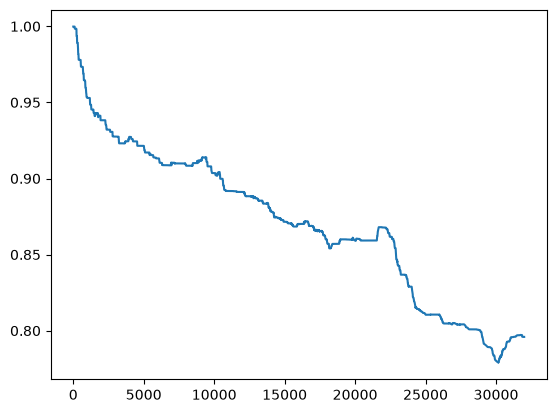

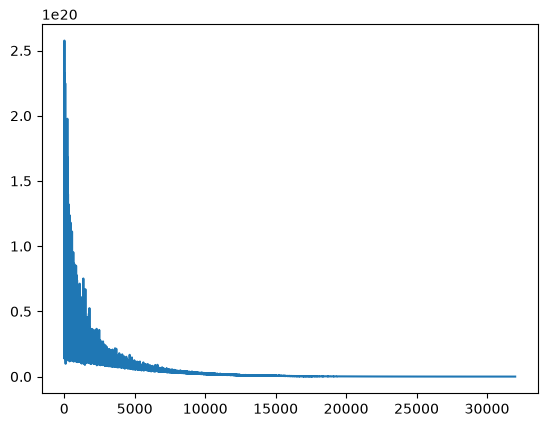

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

t1_5_6 = torch.tensor([[1,1,1,3,3,-4,0],
                       [-2,-2,-2,3,3,-1,0],
                       [3,3,3,1,1,-4,0],
                       [-1,-1,-1,3,3,6,0],
                       [3,3,3,1,1,8,0]]).double()

t2 = torch.randn((5,7)).double()-.5 + t1_5_6


t3 = torch.tensor([
        #  x1-x8: -12 each                 | x9   x10  x11  x12  x13  x14
        [-12, -12, -12, -12, -12, -12, -12, -12, -12, -4, 18, 4, 66, -21,.5],  # H1
        [-12, -12, -12, -12, -12, -12, -12, -12, -12, 3, -15, -15, -65, 41,.5],  # H2
        [-12, -12, -12, -12, -12, -12, -12, -12, -12, 29, 5, -71, 7, -5,.5],  # H3
        [-12, -12, -12, -12, -12, -12, -12, -12, -11, -70, -5, -25, 4, -4,.5],  # H4
        [-12, -12, -12, -12, -12, -12, -12, -12, -12, 3, -51, -5, 13, 41,.5],  # H5
        [-12, -12, -12, -12, -12, -12, -12, -12, -13, -4, 69, 1, -23, -21,.5],  # H6
        [-12, -12, -12, -12, -12, -12, -12, -12, -13, -5, 18, 0, 35, 53,.5],  # H7
        [-12, -12, -12, -12, -12, -12, -12, -12, -12, 5, -34, 7, 10, -57,.5],  # H8
        [-12, -12, -12, -12, -12, -12, -12, -12, -12, 71, 7, 27, 6, 4,.5],  # H9
        [-12, -12, -12, -12, -12, -12, -12, -12, -13, 1, -18, -5, -52, -34,.5],  # H10
        [-12, -12, -12, -12, -12, -12, -12, -12, -13, -30, -6, 76, -3, 3,.5],  # H11
    ]).double()


g, g_agg = g_dict["Prod_Clamp_chat_gen"]


hpoints1, hpoints2 = gen_hypercubes(14)
edge_set = torch.tensor(np.concatenate((hpoints1, hpoints2)).T).double()
print(t3.shape)
#scheduler_fac = lambda optimizer: torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)
#loss_array, val_array = run_adam(6, t1_5_6, 2, g, g_agg,20, edge_set, randomness=False, scheduler_fac=scheduler_fac)

def get_penalty_func(t):
    """
    attempting to remove symmetry by preserving order and sign
    don't think there's a way to vectorize or anything, just want to see what it does

    get signs and orders per row

    use that to make a for loop function with a closure
    ----
    test this in a seperate py file
    with printouts instead of closure function

    """
    pairs = []
    t_signs_mat = torch.zeros(t.shape)
    for r in range(t.shape[0]):
        t_row = []
        for c in range(t.shape[1] - 1):
            t_row.append([c, abs(t[r, c])])
            if t[r, c] > 0:
                t_signs_mat[r, c] = 1
            elif t[r, c] < 0:
                t_signs_mat[r, c] = -1
        t_row.sort(key=lambda x: x[1])
        for i in range(len(t_row)-1):
            c1 = t_row[i][0]
            c2 = t_row[i + 1][0]
            pairs.append([[r, c1], [r, c2]])

    def penalize_g_agg(t):
        out=0
        out += -1*torch.sum(torch.min(torch.zeros(t_signs_mat.shape), t * t_signs_mat))
        for p in pairs:
            v0 = t[*p[0]] * t_signs_mat[*p[0]]
            v1 = t[*p[1]] * t_signs_mat[*p[1]]

            out += -1*torch.min(torch.tensor(0), v1 - v0)
        return out

    return penalize_g_agg

        
            


out = run_adam_find_new(14, t3, g, g_agg,32, edge_set, total_iter=1000, lr=.01, penalty= get_penalty_func(t3))
print(len(out))
perf_array_fixed, loss_array = out[0], out[1]
print(max(perf_array_fixed))
sns.lineplot(perf_array_fixed)
plt.show()
sns.lineplot(loss_array)
plt.show()


In [6]:
t3.shape

torch.Size([11, 15])

/tmp/ipykernel_38351/3825867651.py:208: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  h = torch.tensor(h_desired).double().requires_grad_(True)


[]
k: 11 d: 14 count: 91276
2
0.9998256138392857


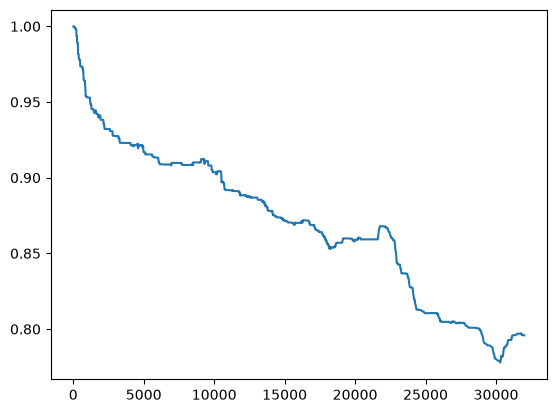

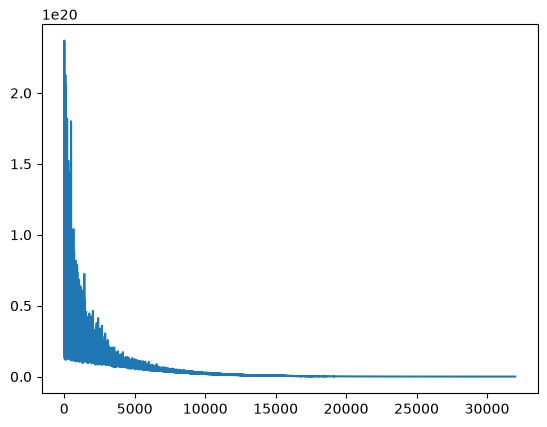

In [21]:
out = run_adam_find_new(14, t3, g, g_agg,32, edge_set,  total_iter=1000, lr=.01, penalty= get_penalty_func(t3))
print(len(out))
perf_array_fixed, loss_array = out[0], out[1]
print(max(perf_array_fixed))
sns.lineplot(perf_array_fixed)
plt.show()
sns.lineplot(loss_array)
plt.show()


So far:

2000 iterations to "zoom out"

Sigmoid just stays 1.8 away from min, so it's stuck in a local minima, randomness doesn't seem to help

Sigmoid gates is 2.0,0.0 without randomness. Val stays zero.


